In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel('C:\\Users\\Noel\\OneDrive - Universidade da Coruña\\00_Grado+Master\\4º\\2º Cuatri\\Trabajo Fin de Grado\\TFG_Datos.xlsx', usecols=['Fecha', 'P','G(i)','H_sun','T2m','WS10m','Int'])

print(df)

                  Fecha    P  G(i)  H_sun   T2m  WS10m  Int
0      2017-01-01 00:01  0.0   0.0    0.0  4.59   2.07  0.0
1      2017-01-01 01:01  0.0   0.0    0.0  4.57   2.07  0.0
2      2017-01-01 02:01  0.0   0.0    0.0  4.76   1.93  0.0
3      2017-01-01 03:01  0.0   0.0    0.0  5.34   1.79  0.0
4      2017-01-01 04:01  0.0   0.0    0.0  5.09   1.79  0.0
...                 ...  ...   ...    ...   ...    ...  ...
35059  2020-12-31 19:01  0.0   0.0    0.0  7.86   4.34  0.0
35060  2020-12-31 20:01  0.0   0.0    0.0  7.75   3.79  0.0
35061  2020-12-31 21:01  0.0   0.0    0.0  7.69   3.24  0.0
35062  2020-12-31 22:01  0.0   0.0    0.0  7.66   3.03  0.0
35063  2020-12-31 23:01  0.0   0.0    0.0  7.54   3.59  0.0

[35064 rows x 7 columns]


In [29]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d %H:%M')
df = df.set_index('Fecha')
df = df.asfreq('H', method='ffill')
df = df.sort_index()
df.head()

C:\Users\Noel\AppData\Local\Temp\ipykernel_21708\2394605671.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H', method='ffill')


,P,G(i),H_sun,T2m,WS10m,Int
Fecha,,,,,,
2017-01-01 00:01:00,0.0,0.0,0.0,4.59,2.07,0.0
2017-01-01 01:01:00,0.0,0.0,0.0,4.57,2.07,0.0
2017-01-01 02:01:00,0.0,0.0,0.0,4.76,1.93,0.0
2017-01-01 03:01:00,0.0,0.0,0.0,5.34,1.79,0.0
2017-01-01 04:01:00,0.0,0.0,0.0,5.09,1.79,0.0


In [30]:
year=24*3600*365.25
seconds=df.index.map(pd.Timestamp.timestamp)
day=24*3600

df['day_sin']=np.sin(seconds*(2*np.pi/day))
df['day_cos']=np.cos(seconds*(2*np.pi/day))
df['year_sin']=np.sin(seconds*(2*np.pi/year))
df['year_cos']=np.cos(seconds*(2*np.pi/year))

df = df.reset_index()
df=df.drop(columns=['Fecha'])
df.drop(columns=['G(i)'], inplace=True)
df = df.dropna()
df= df.loc[:, df.std() > 0]


In [31]:
#Divide data into train, validation and test sets

def train_val_test_split(dataframe, tr_size=0.8, vl_size=0.1, ts_size=0.1 ):
    N = dataframe.shape[0]
    Ntrain = int(tr_size*N)  # Training data
    Nval = int(vl_size*N)    # Validation data


    train = dataframe[0:Ntrain]
    val = dataframe[Ntrain:Ntrain+Nval]
    test = dataframe[Ntrain+Nval:]

    return train, val, test


train,val,test = train_val_test_split(df)

print(f'Train shape: {train.shape}')
print(f'Validation shape: {val.shape}')
print(f'Test shape: {test.shape}')

Train shape: (28051, 8)
Validation shape: (3506, 8)
Test shape: (3507, 8)


In [32]:
from sklearn.preprocessing import StandardScaler

def escalar_dataset(data_train,data_validation,data_test, col_ref):

  NFEATS = data_train.shape[1]

  # List of scalers for each feature
  scalers = [StandardScaler() for _ in range(NFEATS)]

  data_t = np.zeros(data_train.shape)
  data_v = np.zeros(data_validation.shape)
  data_ts = np.zeros(data_test.shape)

  for i, scaler in enumerate(scalers):
      
    data_i = data_train.iloc[:, i].values.reshape(-1, 1)
    data_t[:, i] = scaler.fit_transform(data_i).flatten()

    # Scale data for validation
    data_j = data_validation.iloc[:, i].values.reshape(-1, 1)
    data_v[:, i] = scaler.transform(data_j).flatten()

    # Scale data for test
    data_k = data_test.iloc[:, i].values.reshape(-1, 1)
    data_ts[:, i] = scaler.transform(data_k).flatten()

  return data_t,data_v,data_ts, scalers[data_train.columns.get_loc(col_ref)]

In [33]:
#Save the date columns before scaling
save_col1 = train[['day_sin', 'day_cos', 'year_sin', 'year_cos']].copy()
save_col1.reset_index(drop=True, inplace=True)
save_col1.index += 0

save_col2 = val[['day_sin', 'day_cos', 'year_sin', 'year_cos']].copy()

save_col2.reset_index(drop=True, inplace=True)
save_col2.index += 0

save_col3 = test[['day_sin', 'day_cos', 'year_sin', 'year_cos']].copy()

save_col3.reset_index(drop=True, inplace=True)
save_col3.index += 0

# Scale dataset
tr, vl, ts, scaler = escalar_dataset(train, val, test, col_ref='P')

# Convert results to DataFrame
tr = pd.DataFrame(tr, columns=list(df.columns.values))
vl = pd.DataFrame(vl, columns=list(df.columns.values))
ts = pd.DataFrame(ts, columns=list(df.columns.values))

# Restore the date columns after scaling
tr[['day_sin', 'day_cos', 'year_sin', 'year_cos']] = save_col1
vl[['day_sin', 'day_cos', 'year_sin', 'year_cos']] = save_col2
ts[['day_sin', 'day_cos', 'year_sin', 'year_cos']] = save_col3

In [34]:
def crear_dataset_supervisado(array, input_length, output_length):
   
    X, Y = [], [] 
    fils, cols = array.shape # This is done this way because we have several series (multivariate)

    # Generate the arrays
    for i in range(fils-input_length-output_length):
        #Model input
        X.append(array[i:i+INPUT_LENGTH,0:cols])

        Y.append(array[i+input_length:i+input_length+output_length,0].reshape(output_length,1))

    X = np.array(X)
    Y = np.array(Y)

    return X, Y

In [35]:
# Create datasets for training, validation and testing
INPUT_LENGTH = 24    
OUTPUT_LENGTH = 1    

x_tr, y_tr = crear_dataset_supervisado(tr.values, INPUT_LENGTH, OUTPUT_LENGTH)
x_vl, y_vl = crear_dataset_supervisado(vl.values, INPUT_LENGTH, OUTPUT_LENGTH)
x_ts, y_ts = crear_dataset_supervisado(ts.values, INPUT_LENGTH, OUTPUT_LENGTH)

# Imprimir información en pantalla
print('Input shape (BATCHES x INPUT_LENGTH x FEATURES) and output(BATCHES x OUTPUT_LENGTH x FEATURES)')
print(f'Train set - x_tr: {x_tr.shape}, y_tr: {y_tr.shape}')
print(f'Validation set - x_vl: {x_vl.shape}, y_vl: {y_vl.shape}')
print(f'Test set - x_ts: {x_ts.shape}, y_ts: {y_ts.shape}')

Input shape (BATCHES x INPUT_LENGTH x FEATURES) and output(BATCHES x OUTPUT_LENGTH x FEATURES)
Train set - x_tr: (28026, 24, 8), y_tr: (28026, 1, 1)
Validation set - x_vl: (3481, 24, 8), y_vl: (3481, 1, 1)
Test set - x_ts: (3482, 24, 8), y_ts: (3482, 1, 1)


In [41]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. POSITIONAL ENCODING

class PositionalEncoding(layers.Layer):

    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.d_model = d_model

        # Compute fixed positional encoding matrix
        positions = np.arange(sequence_length)[:, np.newaxis]       # (T, 1)
        dims      = np.arange(d_model)[np.newaxis, :]               # (1, d_model)

        # Standard sine/cosine encoding (Vaswani et al., 2017)
        angles = positions / np.power(10000, (2 * (dims // 2)) / d_model)
        angles[:, 0::2] = np.sin(angles[:, 0::2])   # even indices → sin
        angles[:, 1::2] = np.cos(angles[:, 1::2])   # odd  indices → cos

        self.pos_encoding = tf.cast(angles[np.newaxis, :, :], dtype=tf.float32)  # (1, T, d_model)

    def call(self, x):
        return x + self.pos_encoding[:, :tf.shape(x)[1], :]

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length,
                        "d_model": self.d_model})
        return config

# 2. TRANSFORMER ENCODER BLOCK

class TransformerEncoderBlock(layers.Layer):

    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)

        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout_rate
        )

        # Feed-forward network (two dense layers)
        self.ffn = keras.Sequential([
            layers.Dense(dff, activation="relu"),
            layers.Dense(d_model)
        ])

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        # --- Multi-Head Self-Attention ---
        attn_output = self.attention(x, x, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.norm1(x + attn_output)          # residual connection

        # --- Feed-Forward Network ---
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.norm2(out1 + ffn_output)        # residual connection

        return out2

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.attention.key_dim * self.attention.num_heads,
            "num_heads": self.attention.num_heads,
            "dff": self.ffn.layers[0].units,
        })
        return config

# 3. FULL TRANSFORMER MODEL

def build_transformer(
    sequence_length,     # number of past time steps used as input
    n_features,          # number of input variables (PV power + meteo variables)
    d_model=64,          # embedding dimension
    num_heads=4,         # number of attention heads (d_model must be divisible by num_heads)
    dff=128,             # units in feed-forward network
    num_encoder_blocks=2,# number of stacked encoder blocks
    dropout_rate=0.1,
    output_steps=1       # number of future steps to predict
):

    inputs = keras.Input(shape=(sequence_length, n_features), name="input")

    x = layers.Dense(d_model, name="input_projection")(inputs)


    x = PositionalEncoding(sequence_length, d_model, name="positional_encoding")(x)
    x = layers.Dropout(dropout_rate)(x)

    for i in range(num_encoder_blocks):
        x = TransformerEncoderBlock(
            d_model=d_model,
            num_heads=num_heads,
            dff=dff,
            dropout_rate=dropout_rate,
            name=f"encoder_block_{i+1}"
        )(x)

    x = layers.GlobalAveragePooling1D(name="global_avg_pool")(x)

    x = layers.Dense(64, activation="relu", name="dense_head")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(output_steps, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="Transformer_PV")
    return model

# 4. TRAINING 

def compile_and_train(
    model,
    X_train, y_train,
    X_val,   y_val,
    learning_rate=1e-3,
    epochs=100,
    batch_size=32,
    patience=15          # early stopping patience
):

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
        filepath='best_transformer.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    return history

SEQ_LEN       = 24      # 24-hour input window
N_FEATURES    = 8       #  PV power, GHI, temperature, humidity, wind speed....
OUTPUT_STEPS  = 1       # predict next hour

# Build model
model_transformer = build_transformer(
    sequence_length=SEQ_LEN,
    n_features=N_FEATURES,
    d_model=64,
    num_heads=4,
    dff=128,
    num_encoder_blocks=2,
    dropout_rate=0.1,
    output_steps=OUTPUT_STEPS
)

model_transformer.summary()

#  Train 
history = compile_and_train(
    model_transformer,
    x_tr, y_tr,
    x_vl,   y_vl,
    learning_rate=1e-3,
    epochs=100,
    batch_size=32,
    patience=15
)


Model: "Transformer_PV"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_projection (Dense)        │ (None, 24, 64)         │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 24, 64)         │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_block_1                 │ (None, 24, 64)         │        33,472 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_block_2                 │ (None, 24, 64)         │        33,472 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,745 (280.25 KB)

 Trainable params: 71,745 (280.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
876/876 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - loss: 0.1870 - mae: 0.2618 - val_loss: 0.1087 - val_mae: 0.1758 - learning_rate: 0.0010
Epoch 2/100
876/876 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.1266 - mae: 0.2071 - val_loss: 0.1067 - val_mae: 0.2040 - learning_rate: 0.0010
Epoch 3/100
876/876 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 0.1205 - mae: 0.1986 - val_loss: 0.1109 - val_mae: 0.1912 - learning_rate: 0.0010
Epoch 4/100
876/876 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 0.1168 - mae: 0.1932 - val_loss: 0.0999 - val_mae: 0.1733 - learning_rate: 0.0010
Epoch 5/100
876/876 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 0.1155 - mae: 0.1921 - val_loss: 0.1156 - val_mae: 0.1780 - learning_rate: 0.0010
Epoch 6/100
876/876 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 0.1152 - mae: 0.1897 - val_loss: 0.1072 - val_mae: 0.1879 - learning_rate: 0.0010
Epoch 7/100
876/876 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - loss: 0.1131 - mae: 0.1880 - val_loss: 0.0995 - val_mae: 0.1543 - learnin

In [42]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Predictions
y_pred = model_transformer.predict(x_ts)

#Unscale
y_real = scaler.inverse_transform(y_ts.reshape(-1, 1)).flatten()
y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

# Mask, delete pure night, keep transitions
def mask_night(real):
    n = len(real)
    keep = np.zeros(n, dtype=bool)
    for i in range(n):
        if real[i] != 0:
            keep[i] = True
        else:
            prev_nonzero = (i > 0)     and (real[i-1] != 0)
            next_nonzero = (i < n-1)   and (real[i+1] != 0)
            keep[i] = prev_nonzero or next_nonzero
    return keep

mask = mask_night(y_real)
y_real_m = y_real[mask]
y_pred_m = y_pred[mask]

mask_n = mask[:-1] & mask[1:]  

#Naïve (persistence) with the same mask
y_naive_m  = y_real[:-1][mask_n]
y_true_n_m = y_real[1:][mask_n]
y_pred_n_m = y_pred[1:][mask_n]




# Metrics
def mMAPE(real, pred):
    y_max = np.max(np.abs(real))
    if y_max < 1:
        return 100 * np.mean(np.abs(real - pred))
    return 100 * np.mean(np.abs(real - pred) / y_max)

def forecast_skill(real, pred, naive):
    rmse_model = np.sqrt(mean_squared_error(real, pred))
    rmse_naive = np.sqrt(mean_squared_error(real, naive))
    return 1 - (rmse_model / rmse_naive)

mse  = mean_squared_error(y_real_m, y_pred_m)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_real_m, y_pred_m)
r2   = r2_score(y_real_m, y_pred_m)
mape = mMAPE(y_real_m, y_pred_m)
fs   = forecast_skill(y_true_n_m, y_pred_n_m, y_naive_m)

print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")
print(f"R²    : {r2:.4f}")
print(f"mMAPE : {mape:.4f}%")
print(f"FS    : {fs:.4f}")


109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
MSE   : 10631.4924
RMSE  : 103.1091
MAE   : 65.4227
R²    : 0.8054
mMAPE : 7.9680%
FS    : 0.2906


In [43]:
# Metrics Naïve complete
mse_n  = mean_squared_error(y_true_n_m, y_naive_m)
rmse_n = np.sqrt(mse_n)
mae_n  = mean_absolute_error(y_true_n_m, y_naive_m)
r2_n   = r2_score(y_true_n_m, y_naive_m)
mape_n = mMAPE(y_true_n_m, y_naive_m)

# Compare metrics in a table 
metrics = ["MSE", "RMSE", "MAE", "R²", "mMAPE (%)", "FS"]
Transformer_vals   = [mse,   rmse,   mae,   r2,   mape,   fs]
naive_vals = [mse_n, rmse_n, mae_n, r2_n, mape_n, None]

print("=" * 50)
print(f"{'Metric':<12} {'Transformer':>12} {'Naïve':>12}")
print("=" * 50)
for m, x, n in zip(metrics, Transformer_vals, naive_vals):
    x_str = f"{x:.4f}"
    n_str = f"{n:.4f}" if n is not None else "N/A"
    # Ok if Transformer is better (lower MSE, RMSE, MAE, mMAPE; higher R²; higher FS)
    if n is not None:
        better = x < n if m != "R²" else x > n
        flag = " OK" if better else " NO"
    else:
        flag = ""
    print(f"{m:<12} {x_str:>12} {n_str:>12}{flag}")
print("=" * 50)
print(f"{'FS > 0 → Transformer overperforms Naïve':>50}")
print(f"{'FS < 0 → Naïve is better':>50}")
print("=" * 50)

Metric        Transformer        Naïve
MSE            10631.4924   22991.5198 OK
RMSE             103.1091     151.6295 OK
MAE               65.4227     111.9514 OK
R²                 0.8054       0.5778 OK
mMAPE (%)          7.9680      13.6348 OK
FS                 0.2906          N/A
           FS > 0 → Transformer overperforms Naïve
                          FS < 0 → Naïve is better


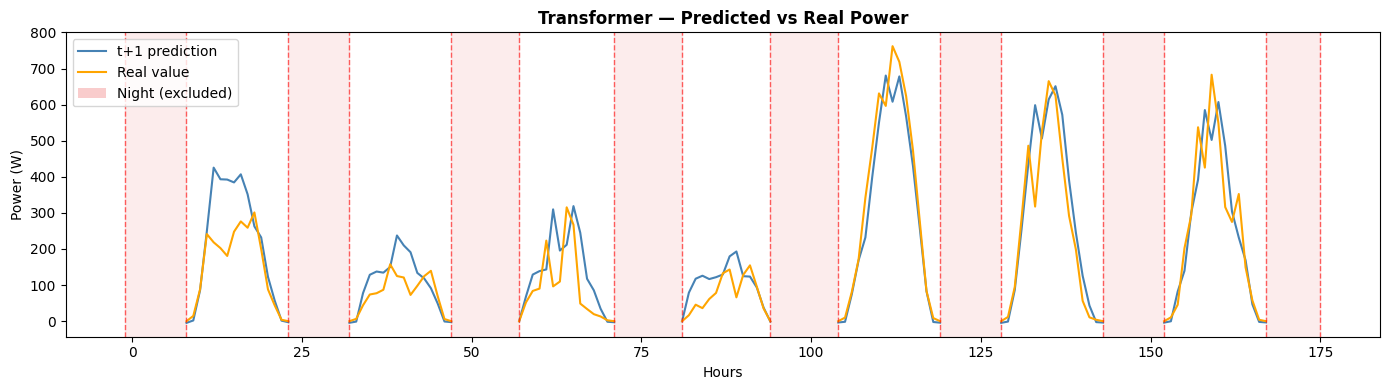

In [44]:
import numpy as np
import matplotlib.pyplot as plt
hpredic = 175

y_real_plot = y_real[:hpredic].flatten()
y_pred_plot = y_pred[:hpredic].flatten()

def insert_nan_nights(real, pred):
    n = len(real)
    r = real.copy().astype(float)
    p = pred.copy().astype(float)
    for i in range(n):
        if real[i] == 0:
            prev_nonzero = (i > 0)   and (real[i-1] != 0)
            next_nonzero = (i < n-1) and (real[i+1] != 0)
            if not (prev_nonzero or next_nonzero):
                r[i] = np.nan
                p[i] = np.nan
    return r, p

y_real_clean, y_pred_clean = insert_nan_nights(y_real_plot, y_pred_plot)

is_nan  = np.isnan(y_real_clean)
n       = len(is_nan)
night_blocks = []
i = 0
while i < n:
    if is_nan[i]:
        start = i
        while i < n and is_nan[i]:
            i += 1
        night_blocks.append((start-1, i))
    else:
        i += 1

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(y_pred_clean, label='t+1 prediction', color='steelblue', lw=1.5)
ax.plot(y_real_clean, label='Real value',      color='orange',    lw=1.5)


for start, end in night_blocks:
    ax.axvspan(start, end, color='lightcoral', alpha=0.15, zorder=0)
    ax.axvline(x=start, color='red', lw=1.0, linestyle='--', alpha=0.6)
    ax.axvline(x=end,   color='red', lw=1.0, linestyle='--', alpha=0.6)

from matplotlib.patches import Patch
night_patch = Patch(facecolor='lightcoral', alpha=0.4, label='Night (excluded)')
ax.legend(handles=[
    plt.Line2D([0],[0], color='steelblue', lw=1.5, label='t+1 prediction'),
    plt.Line2D([0],[0], color='orange',    lw=1.5, label='Real value'),
    night_patch
])

ax.set_xlabel('Hours')
ax.set_ylabel('Power (W)')
ax.set_title('Transformer — Predicted vs Real Power', fontweight='bold')
plt.tight_layout()
plt.show()

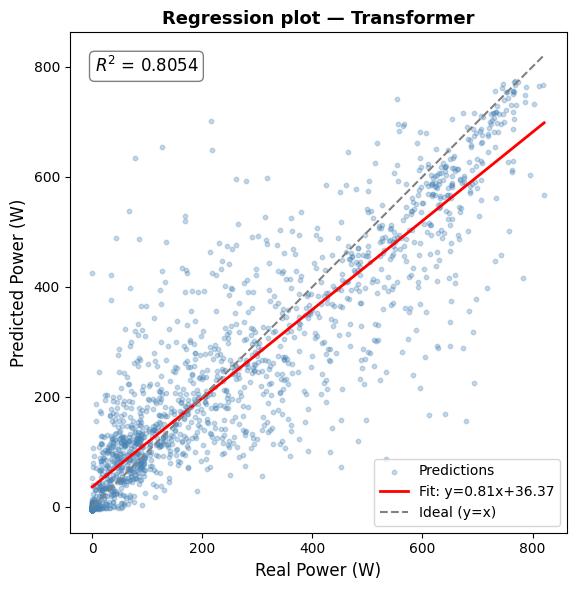

R²     : 0.8054
Slope  : 0.8058
Intercept: 36.3709


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


m, b = np.polyfit(y_real_m.flatten(), y_pred_m.flatten(), 1)
r2   = r2_score(y_real_m.flatten(), y_pred_m.flatten())


fig, ax = plt.subplots(figsize=(6, 6))

# Points
ax.scatter(y_real_m, y_pred_m, alpha=0.3, s=10, color='steelblue', label='Predictions')

# Regression line
x_line = np.linspace(y_real_m.min(), y_real_m.max(), 200)
ax.plot(x_line, m * x_line + b, color='red', lw=2, label=f'Fit: y={m:.2f}x+{b:.2f}')

# Ideal line
ax.plot(x_line, x_line, color='gray', lw=1.5, linestyle='--', label='Ideal (y=x)')

# R² annotation
ax.text(0.05, 0.92, f'$R^2$ = {r2:.4f}',
        transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))

ax.set_xlabel('Real Power (W)', fontsize=12)
ax.set_ylabel('Predicted Power (W)', fontsize=12)
ax.set_title('Regression plot — Transformer', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"R²     : {r2:.4f}")
print(f"Slope  : {m:.4f}")
print(f"Intercept: {b:.4f}")

In [63]:
def pfi_modelo(model, x, y, cols):

    NFEATS = x.shape[2] 


    resultados = []

    # 1. Estimate the original error of the trained model
    mse_orig = model.evaluate(x, y, verbose = 0)

    # 2. Iterate over each column and for each iteration:
    # 2.1. Permute the column
    # 2.2. Calculate rmse_perm
    # 2.3. Calculate pfi = rmse_perm/rmse_orig
    # 2.4. Store the result
    for k in range(NFEATS):
        print(f'\tCalculando feature_importance variable {k+1}/{NFEATS}')

        # Swap covariate k
        save_col = x[:,:,k].copy() 
        np.random.shuffle(x[:,:,k]) # Randomly permute it

        # Calculate rmse_perm
        mse_perm = model.evaluate(x, y, verbose=0)

        # Calculate quotient (pfi)
        pfi = mse_perm[1]/mse_orig[1]

        # Store in "resultados"
        resultados.append({'feature':cols[k],'feature_importance':pfi})

        # And restore the covariate to its original position (necessary
        # for the next iteration)
        x[:,:,k] = save_col

    pfis = pd.DataFrame(resultados).sort_values(by='feature_importance', ascending=False)

    return pfis

feat_imp = pfi_modelo(model_transformer,
                      x_vl,
                      y_vl,
                      df.columns)
feat_imp

	Calculando feature_importance variable 1/8
	Calculando feature_importance variable 2/8
	Calculando feature_importance variable 3/8
	Calculando feature_importance variable 4/8
	Calculando feature_importance variable 5/8
	Calculando feature_importance variable 6/8
	Calculando feature_importance variable 7/8
	Calculando feature_importance variable 8/8


,feature,feature_importance
0,P,3.694284
1,H_sun,1.703761
4,day_sin,1.702979
5,day_cos,1.306299
2,T2m,1.123894
7,year_cos,1.033580
3,WS10m,1.019099
6,year_sin,1.015111


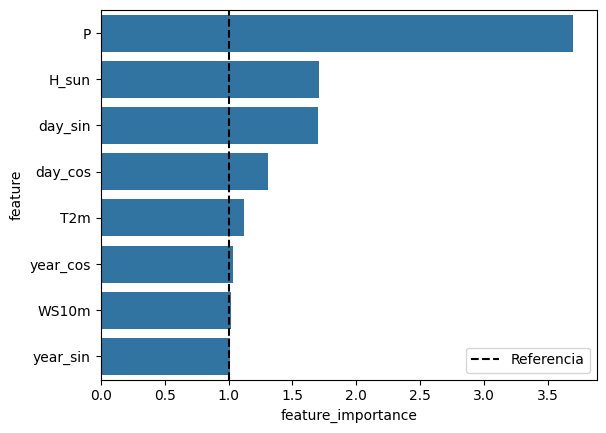

In [64]:
import seaborn as sns

ax = sns.barplot(data=feat_imp, x='feature_importance', y='feature')
ax.axvline(1.0, color='k', linestyle='--', label='Referencia')
ax.legend();